In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sc
from scipy.optimize import minimize
import string

## Load Global Warming Data

In [2]:
moc_01_w =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=01_nonlinear_winter_trans_diffusion_f2=00.txt")
nmoc_01_w =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=01_nonlinear_winter_trans_diffusion_f2=00.txt.")
moc_02_w =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=02_nonlinear_winter_trans_diffusion_f2=00.txt")
nmoc_02_w =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=02_nonlinear_winter_trans_diffusion_f2=00.txt")
moc_03_w =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=03_nonlinear_winter_trans_diffusion_f2=00.txt")
nmoc_03_w =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=03_nonlinear_winter_trans_diffusion_f2=00.txt")
moc_04_w =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=04_nonlinear_winter_trans_diffusion_f2=00.txt")
nmoc_04_w =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=04_nonlinear_winter_trans_diffusion_f2=00.txt")

## Load Hosing Data

In [3]:
moc_02_h =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=00_nonlinear_winter_trans_diffusion_f2=02.txt")
nmoc_02_h =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=00_nonlinear_winter_trans_diffusion_f2=02.txt")
moc_03_h =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=00_nonlinear_winter_trans_diffusion_f2=03.txt")
nmoc_03_h =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=00_nonlinear_winter_trans_diffusion_f2=03.txt")
moc_04_h =  np.loadtxt("./boxmodel_data/MOC_hysteresis_forward_dT=00_nonlinear_winter_trans_diffusion_f2=04.txt")
nmoc_04_h =  np.loadtxt("./boxmodel_data/NMOC_hysteresis_forward_dT=00_nonlinear_winter_trans_diffusion_f2=04.txt")

In [12]:
secy = 86400*365     #seconds in a year
boxvol=1e16          #reference box volume 
fact=boxvol/1e6/secy
V = [13.8,0.68,0.1,0.05,0.7,2.9,13.6, 6.12]  
moc_eq = 16.956901226849272
noc_eq = 5.9263676192032815
T_eq = [2.715287336583422,23.15269776015073,3.019006540872132,0.08124089929796212,0.286483914888759,3.9703131105825733,4.0832479939175315,10.159394812726447]
S_eq = [34.46530756275107,36.00452907870054,35.04203415934926,34.93464173697228,34.94020582807653,35.040969497208685,35.04499719972064,35.069023336596025]

## Figure 4

<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
C:\Users\m301193\AppData\Local\Temp\ipykernel_16508\3241106599.py:8: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(t, moc_01_w[:,1], color="lightblue", label="0.1 $^\circ$C/dec")
C

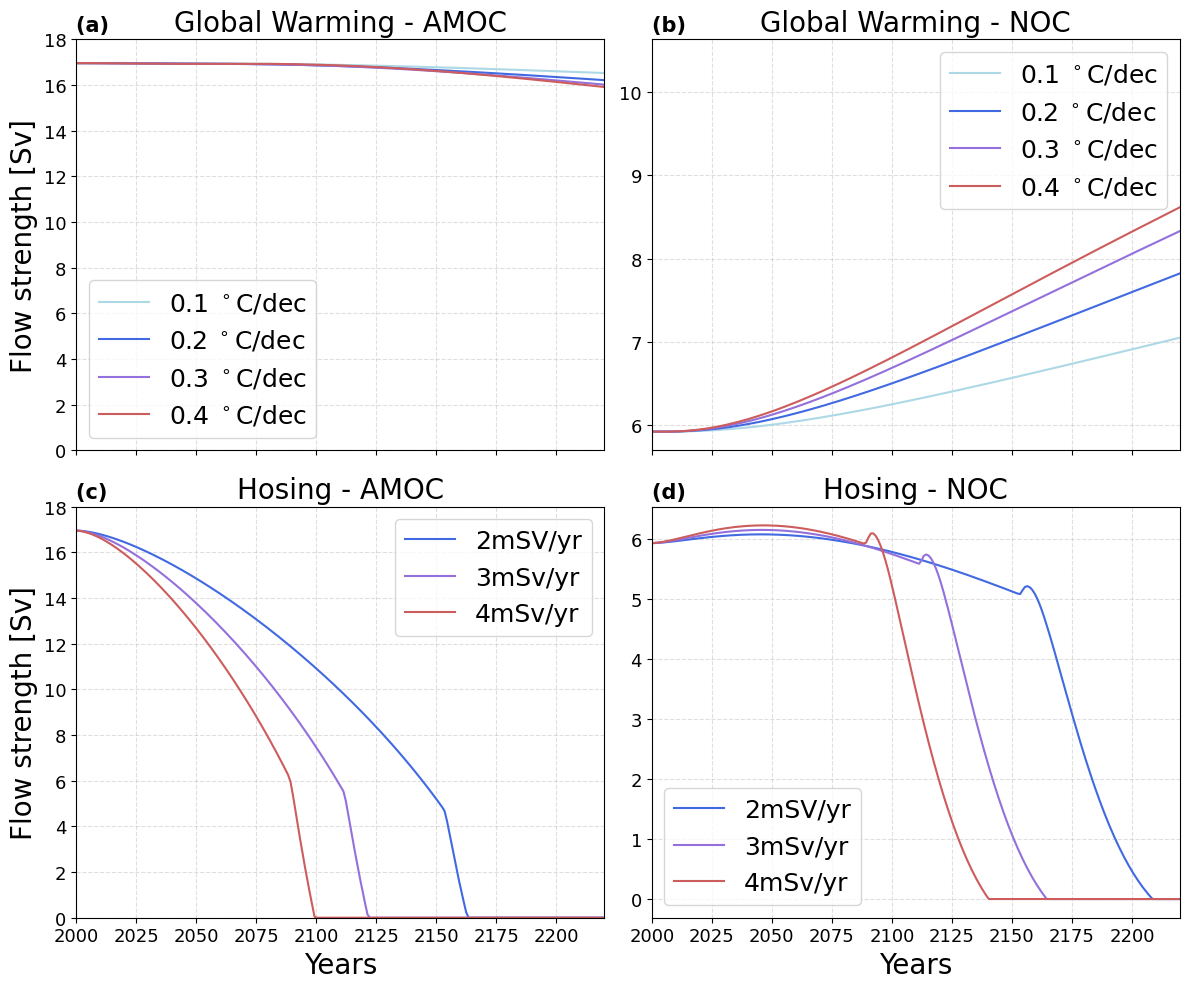

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=100, sharex=True)
t = np.linspace(2000, 2350, 350)
#Global Warming - AMOC
ax = axes[0, 0]
ax.set_title("Global Warming - AMOC", size=20)
ax.plot(t, moc_01_w[:,1], color="lightblue", label="0.1 $^\circ$C/dec")
ax.plot(t, moc_02_w[:,1], color="royalblue", label="0.2 $^\circ$C/dec")
ax.plot(t, moc_03_w[:,1], color="mediumpurple", label="0.3 $^\circ$C/dec")
ax.plot(t, moc_04_w[:,1], color="indianred", label="0.4 $^\circ$C/dec")
ax.legend(fontsize=18)
ax.set_ylabel("Flow strength [Sv]", size=20)
ax.set_xlim(2000, 2220)
ax.set_ylim(0, 18)
ax.grid(True, linestyle="--", alpha=0.4)

#Global Warming - NOC
ax = axes[0, 1]
ax.set_title("Global Warming - NOC", size=20)
ax.plot(t, nmoc_01_w[:,1], color="lightblue",  label="0.1 $^\circ$C/dec")
ax.plot(t, nmoc_02_w[:,1], color="royalblue",  label="0.2 $^\circ$C/dec")
ax.plot(t, nmoc_03_w[:,1], color="mediumpurple", label="0.3 $^\circ$C/dec")
ax.plot(t, nmoc_04_w[:,1], color="indianred", label="0.4 $^\circ$C/dec")
ax.legend(fontsize=18)
ax.set_xlim(2000, 2220)
ax.grid(True, linestyle="--", alpha=0.4)

#Hosing - AMOC
ax = axes[1, 0]
ax.set_title("Hosing - AMOC", size=20)
ax.plot(t, moc_02_h[:,1], color="royalblue", label="2mSV/yr")
ax.plot(t, moc_03_h[:,1], color="mediumpurple", label= "3mSv/yr")
ax.plot(t, moc_04_h[:,1], color="indianred", label="4mSv/yr")
ax.legend(fontsize=18)
ax.set_xlabel("Years", size=20)
ax.set_ylabel("Flow strength [Sv]", size=20)
ax.set_xlim(2000, 2220)
ax.set_ylim(0, 18)
ax.grid(True, linestyle="--", alpha=0.4)

#Hosing - NOC
ax = axes[1, 1]
ax.set_title("Hosing - NOC", size=20)
ax.plot(t, nmoc_02_h[:,1], color="royalblue",label="2mSV/yr")
ax.plot(t, nmoc_03_h[:,1], color="mediumpurple", label= "3mSv/yr")
ax.plot(t, nmoc_04_h[:,1], color="indianred", label="4mSv/yr")

ax.set_xlabel("Years", size=20)
ax.legend(fontsize=18)
ax.set_xlim(2000, 2220)
ax.grid(True, linestyle="--", alpha=0.4)
axes_flat = axes.flatten()
for idx, ax in enumerate(axes_flat):
    label = f"({string.ascii_lowercase[idx]}) "   # (a), (b), (c) ...
    ax.set_title(label, fontweight="bold", loc="left",fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    
plt.tight_layout()
#plt.savefig("./results_hysteresis_final/global_warming_hosing_subplot.pdf", dpi = 300)
plt.show()

## Figure 3

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
C:\Users\m301193\AppData\Local\Temp\ipykernel_16772\2141859176.py:6: SyntaxWarning: invalid escape sequence '\c'
  labels = ["0.1 $^\circ$C/dec", "0.2 $^\circ$C/dec", "0.3 $^\circ$C/dec", "0.4 $^\circ$C/dec"]
C:\Users\m301193\AppData\Local\Temp\ipykernel_16772\2141859176.py:6: SyntaxWarning: invalid escape sequence '\c'
  labels = ["0.1 $^\circ$C/dec", "0.2 $^\circ$C/dec", "0.3 $^\circ$C/dec",

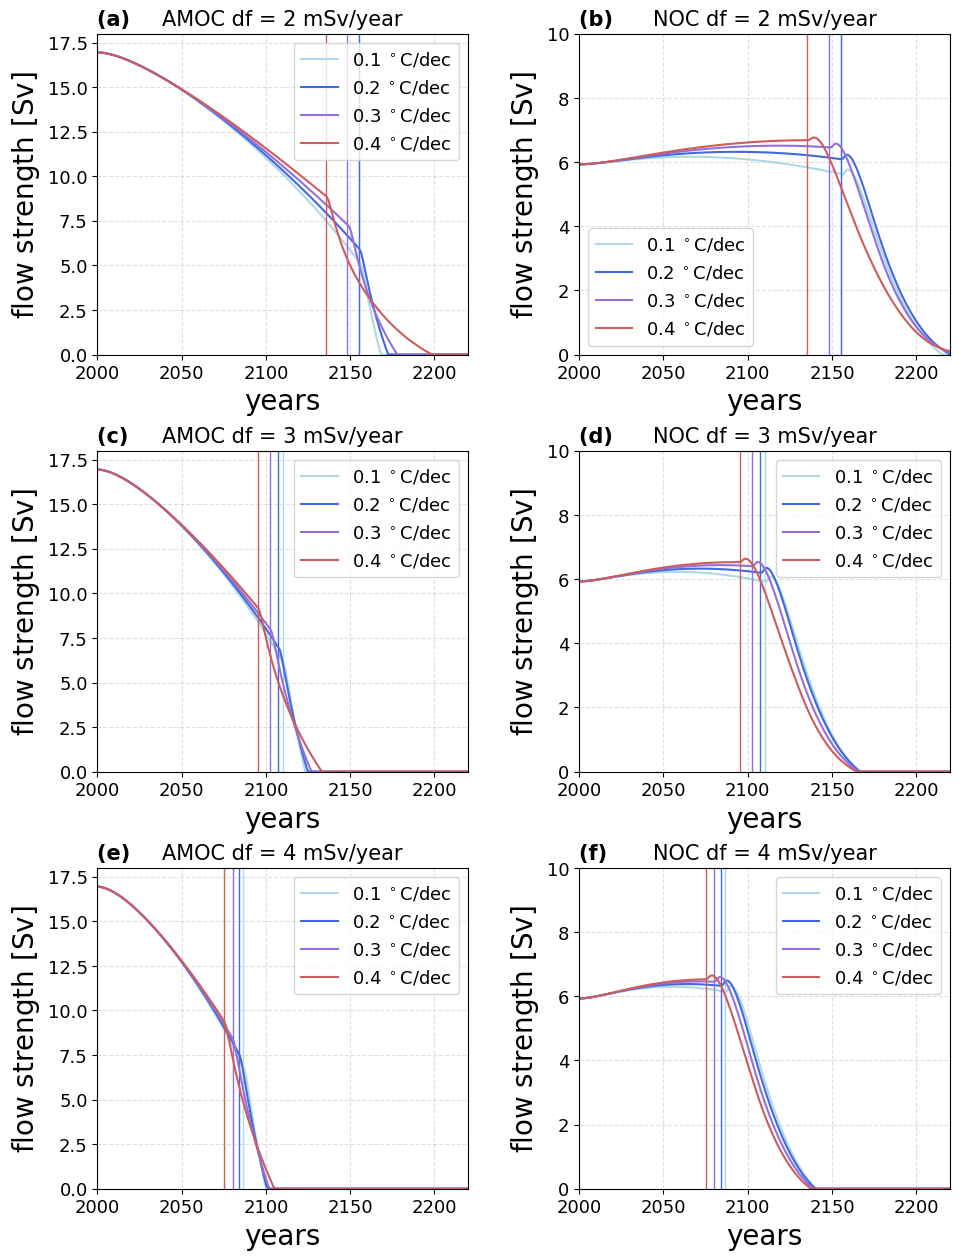

In [6]:
df_list = ["02", "03", "04"]
dT_list = ["01", "02", "03", "04"]
title_moc = ["(a)","(c)", "(e)"]
title_nmoc = ["(b)", "(d)","(f)"]
colors = ["lightblue", "royalblue", "mediumpurple", "indianred"]
labels = ["0.1 $^\circ$C/dec", "0.2 $^\circ$C/dec", "0.3 $^\circ$C/dec", "0.4 $^\circ$C/dec"]

t = np.linspace(2000, 2350, 350)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(11, 15), dpi=100, sharex=False, sharey = False)
fig.subplots_adjust(hspace=0.3, wspace=0.3)
axes_flat = axes.flatten()


for idx, ax in enumerate(axes_flat):
    label = f"({string.ascii_lowercase[idx]}) "   
    ax.set_title(label, fontweight="bold", loc="left",fontsize=15)

for i, df in enumerate(df_list):
    ax_moc = axes[i, 0]
    ax_nmoc = axes[i, 1]

    ax_moc.set_title(f"AMOC df = {int(df)} mSv/year",
                     fontsize=15, loc="center")
    ax_nmoc.set_title(f"NOC df = {int(df)} mSv/year",
                      fontsize=15, loc="center")
    
    for j, dT in enumerate(dT_list):
        # Load MOC, NMOC, and convection data
        moc = np.loadtxt(f"./boxmodel_data/MOC_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}.txt")
        nmoc = np.loadtxt(f"./boxmodel_data/NMOC_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}.txt")
        conv = np.loadtxt(f"./boxmodel_data/conv_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}.txt")

        # Plot MOC
        ax_moc.plot(t, moc[:, 1], color=colors[j], label=labels[j])
        # Plot NMOC
        ax_nmoc.plot(t, nmoc[:, 1], color=colors[j], label=labels[j])
        ax_nmoc.set_ylim(0,10)
        # Add vertical line where convection deviates from 0.3
        idx = np.where(conv[1:] != 0.3)[0]
        if len(idx) > 1:
            conv_time = t[idx[0]]
            ax_moc.vlines(conv_time, 0, 20, color=colors[j], linewidth=1)
            ax_nmoc.vlines(conv_time, 0, 20, color=colors[j], linewidth=1)
            
        ax_moc.set_ylabel("flow strength $\mathrm{[Sv]}$", size = 20)
        ax_moc.set_xlabel("years", size = 20)
        ax_moc.set_xlim(2000,2220)
        ax_moc.legend(fontsize = 13)
        
        ax_nmoc.set_ylabel("flow strength $\mathrm{[Sv]}$", size = 20)
        ax_nmoc.set_xlabel("years", size = 20)
        ax_nmoc.set_xlim(2000,2220)
        ax_nmoc.legend(fontsize = 13)

        ax_moc.tick_params(axis='both', labelsize=13)
        ax_nmoc.tick_params(axis='both', labelsize=13)
        
    ax_moc.set_ylim(0, 18)
    ax_nmoc.set_ylim(0, 10)
    ax_moc.grid(True, linestyle="--", alpha=0.4)
    ax_nmoc.grid(True, linestyle="--", alpha=0.4)
    
#plt.savefig("AMOC_NOC_convection_shutdown_comparison_6_panels.pdf", dpi = 300)

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\m'
C:\Users\m301193\AppData\Local\Temp\ipykernel_6600\2727364211.py:6: SyntaxWarning: invalid escape sequence '\c'
  labels = ["AMOC 0.1 $^\circ$C/dec", "AMOC 0.2 $^\circ$C/dec", "AMOC 0.3 $^\circ$C/dec", "AMOC 0.4 $^\circ$C/dec"]
C:\Users\m301193\AppData\Local\Temp\ipykernel_6600\2727364211.py:6: SyntaxWarning: invalid escape sequence '\c'
  labels = ["AMOC 0.1 $^\circ$C/dec", "AMOC 0.2 $^\circ$C/dec", "AMOC 0.3 $^\circ$C/dec", "AMOC 0.4 $^\circ$C/dec"]
C:\Users\m301193\AppData\Local\Temp\ipyker

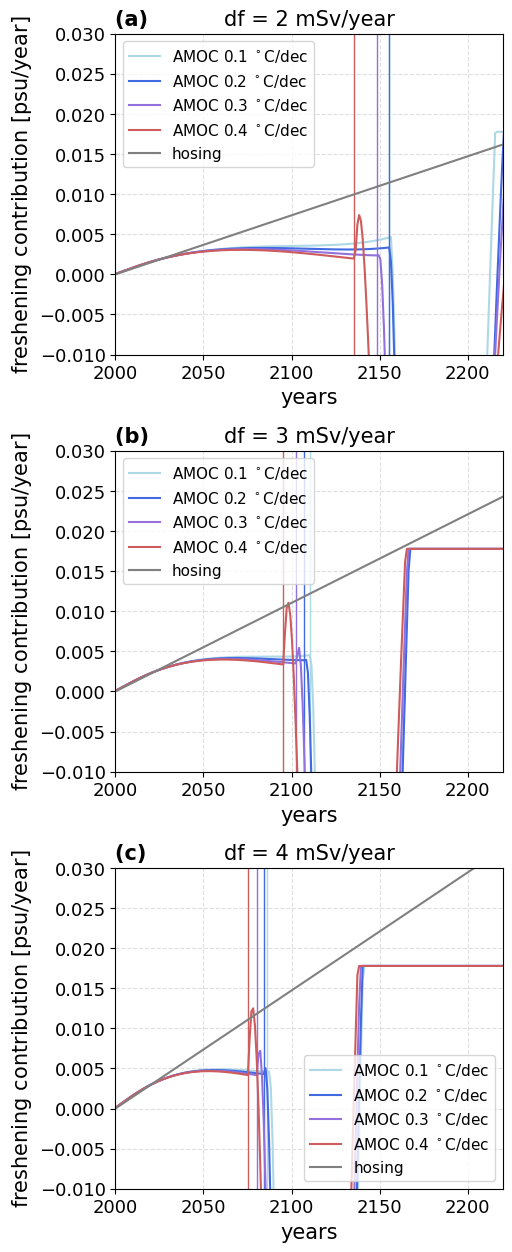

In [34]:
df_list = ["02", "03", "04"]
dT_list = ["01", "02", "03", "04"]
title_moc = ["(a)","(c)", "(e)"]
title_nmoc = ["(b)", "(d)","(f)"]
colors = ["lightblue", "royalblue", "mediumpurple", "indianred"]
labels = ["AMOC 0.1 $^\circ$C/dec", "AMOC 0.2 $^\circ$C/dec", "AMOC 0.3 $^\circ$C/dec", "AMOC 0.4 $^\circ$C/dec"]

t = np.linspace(2000, 2350, 350)
secy = 86400*365     #seconds in a year
boxvol=1e16          #reference box volume 
fact=boxvol/1e6/secy
V = [13.8,0.68,0.1,0.05,0.7,2.9,13.6, 6.12]  

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 15), dpi=100, sharex=False, sharey = False)
fig.subplots_adjust(hspace=0.3, wspace=0.3)
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    label = f"({string.ascii_lowercase[idx]}) "   
    ax.set_title(label, fontweight="bold", loc="left",fontsize=15)

for i, df in enumerate(df_list):
    ax_moc = axes[i]
    
    ax_moc.set_title(f"df = {int(df)} mSv/year",
                     fontsize=15, loc="center")

    
    for j, dT in enumerate(dT_list):
        # Load MOC, NMOC, and convection data
        moc = np.loadtxt(f"./boxmodel_data/MOC_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}_review1.txt")
        noc = np.loadtxt(f"./boxmodel_data/NMOC_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}_review1.txt")
        sal = np.loadtxt(f"./boxmodel_data/S_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}_review1.txt")
        conv = np.loadtxt(f"./boxmodel_data/conv_hysteresis_forward_dT={dT}_nonlinear_winter_trans_diffusion_f2={df}.txt")
        
        
        ax_moc.plot(t, (0.0333*(S_eq[1]-S_eq[2])*moc_eq/fact/V[2] + (1-0.0333)*(S_eq[7]-S_eq[5])*moc_eq/fact/V[5] + 0.0333*(moc_eq-noc_eq)*(S_eq[2]-S_eq[5])/V[5])-(np.array(0.0333*(sal[1,:]-sal[2,:])*moc[:]/fact)/V[2] + np.array((1-0.0333)*(sal[7,:]-sal[5,:])*moc[:]/fact)/V[5]+ 0.0333*(moc[:]-noc[:])*(sal[2,:]-sal[5,:])/V[5]), color=colors[j], label=labels[j])
    
        ax_moc.set_ylabel("freshening contribution $\mathrm{[psu/year]}$", size = 15)
        ax_moc.set_xlabel("years", size = 15)
        ax_moc.set_xlim(2000,2220)

        idx = np.where(conv[1:] != 0.3)[0]
        if len(idx) > 1:
            conv_time = t[idx[0]]
            ax_moc.vlines(conv_time, -10, 20, color=colors[j], linewidth=1)

        ax_moc.tick_params(axis='both', labelsize=13)
        
    ax_moc.plot(t, 35*(int(df)/1000*(t-2000))/fact/((V[2]+V[5])) , color= "gray", label= "hosing")
    ax_moc.legend(fontsize = 11)
    ax_moc.set_ylim(-0.01, 0.03)
    ax_moc.grid(True, linestyle="--", alpha=0.4)

#plt.savefig("fig06.pdf", dpi = 300,bbox_inches='tight')